Calculating weights for sampling...


100%|██████████| 637/637 [00:00<00:00, 386149.97it/s]

Training set has 637 images.
Test set has 160 images.


Using device: cuda
Starting model training for 2-class problem with weighted sampling...
  Batch 50/160, Loss: 1.2168
  Batch 100/160, Loss: 1.1468
  Batch 150/160, Loss: 1.1442
Epoch #1 loss: 1.2168
  Batch 50/160, Loss: 0.8258
  Batch 100/160, Loss: 1.0110
  Batch 150/160, Loss: 0.5885
Epoch #2 loss: 0.9100
  Batch 50/160, Loss: 0.8224
  Batch 100/160, Loss: 0.7743
  Batch 150/160, Loss: 0.8147
Epoch #3 loss: 0.7964
  Batch 50/160, Loss: 0.5908
  Batch 100/160, Loss: 0.6779
  Batch 150/160, Loss: 0.7701
Epoch #4 loss: 0.6786
  Batch 50/160, Loss: 0.7511
  Batch 100/160, Loss: 0.5684
  Batch 150/160, Loss: 0.6489
Epoch #5 loss: 0.6485
  Batch 50/160, Loss: 0.5904
  Batch 100/160, Loss: 0.5153
  Batch 150/160, Loss: 0.6045
Epoch #6 loss: 0.6291
  Batch 50/160, Loss: 0.5788
  Batch 100/160, Loss: 0.5691
  Batch 150/160, Loss: 0.4659
Epoch #7 loss: 0.6093
  Batch 50/160, Loss: 0.6218
  Batch 100/160, Loss: 0.4361
  Batch 150/160, Loss: 0.7685
Epoch #8 loss: 0.6076
  Batch 50/160, Loss: 0

C:\Users\shiva\AppData\Local\Temp\ipykernel_4072\3079049521.py:292: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(ANALYSIS_FOLD


Visualizing predictions on test images...


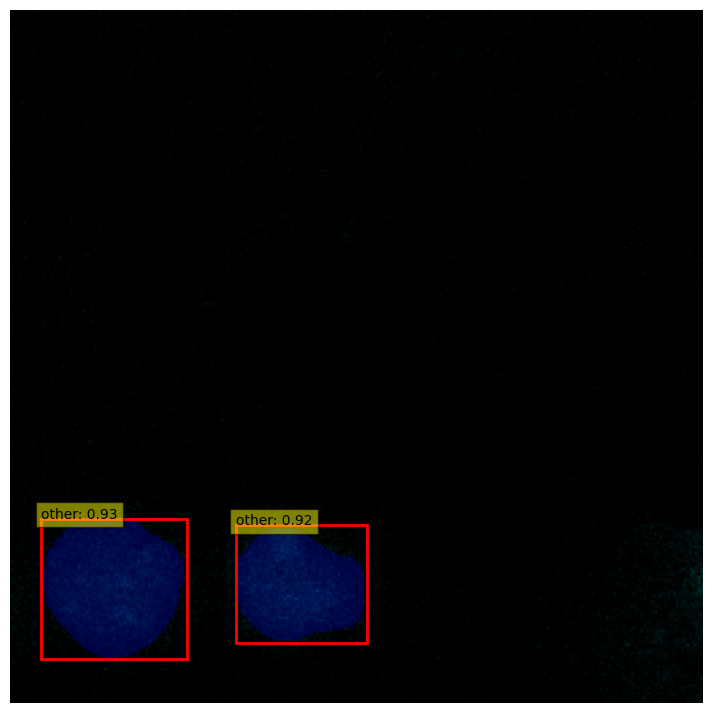

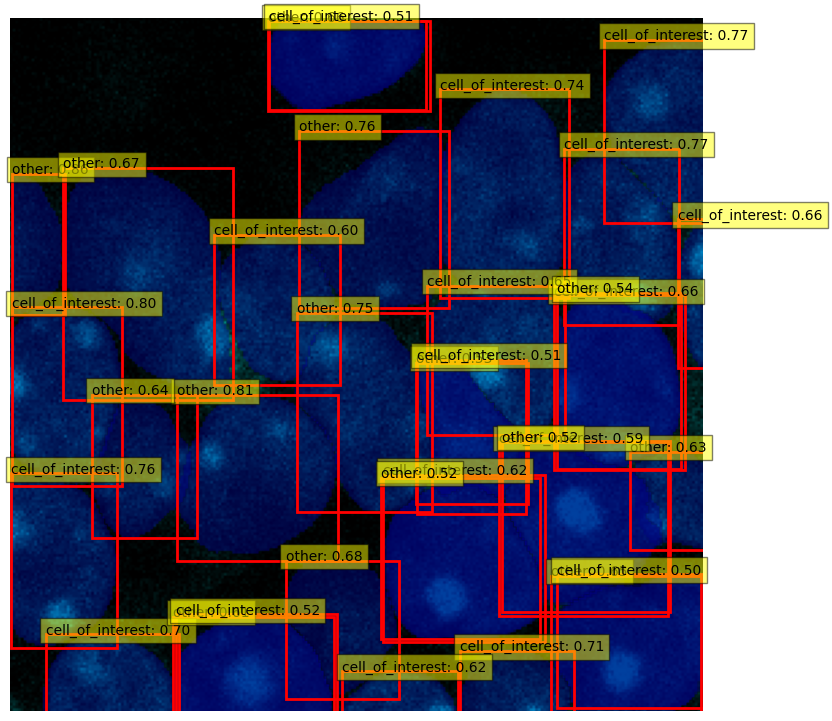

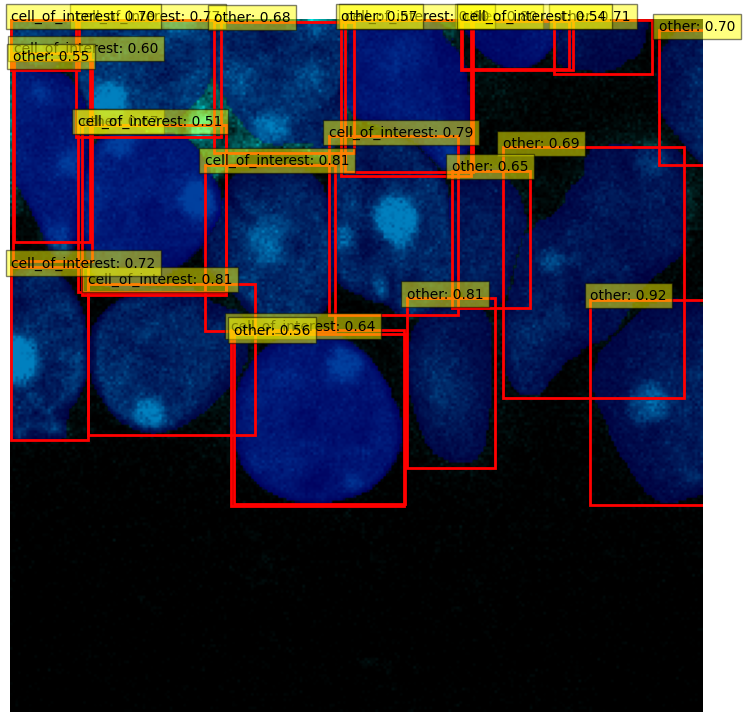

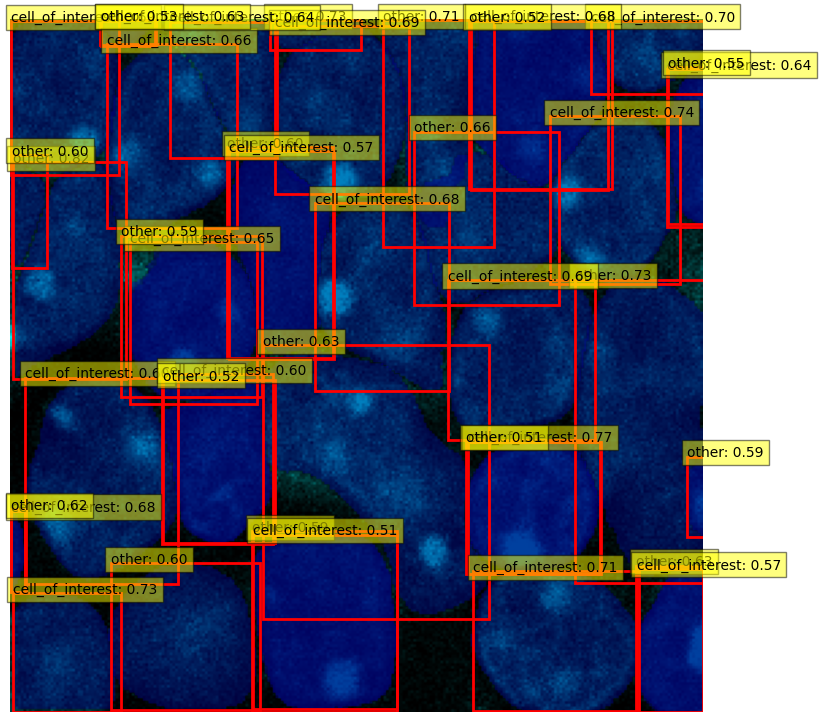

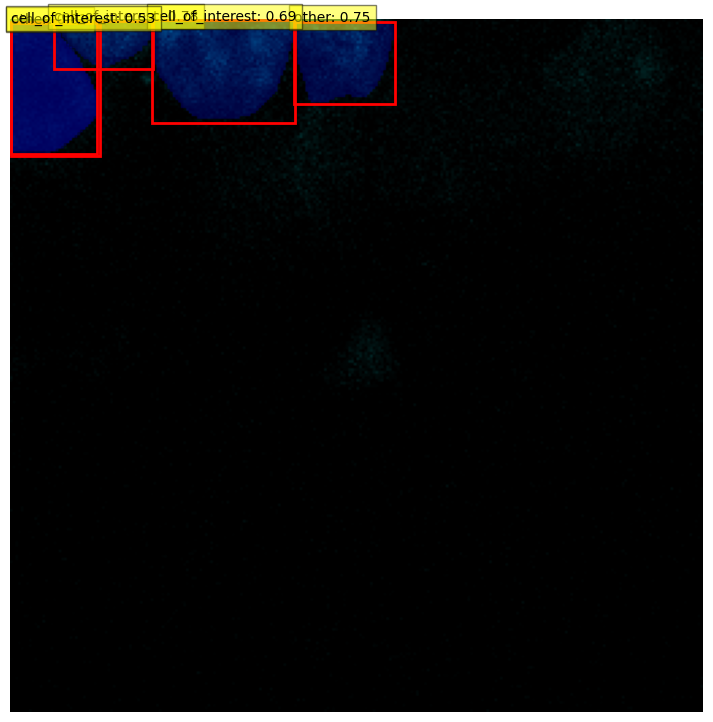


Generating Confusion Matrix...
Confusion matrix, without normalization


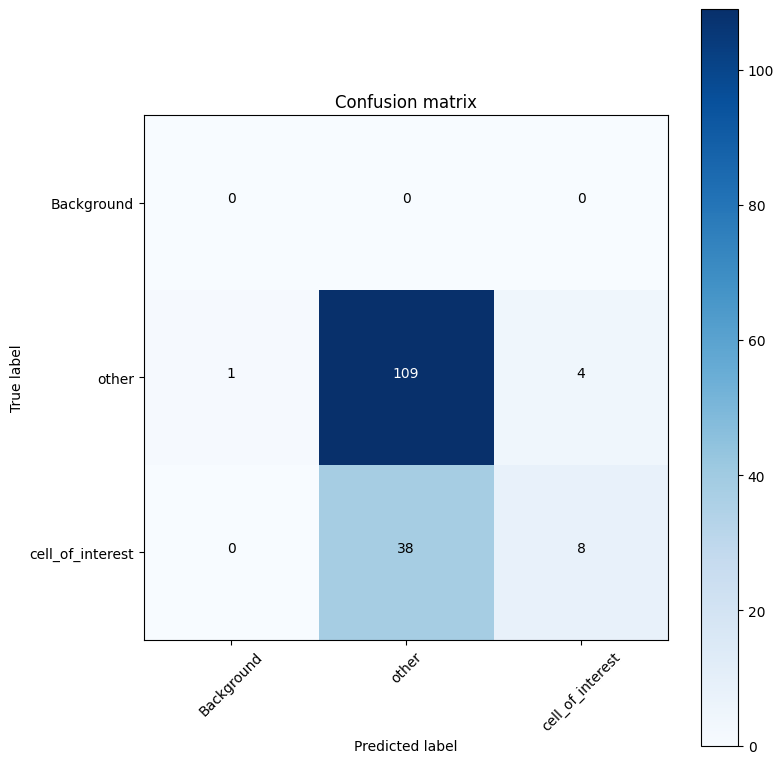

In [ ]:
import os
import json
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import itertools
from pycocotools import mask as mask_util # Import the pycocotools mask utility
from collections import Counter
from tqdm import tqdm

# --- 1. FILE PATHS AND CONFIGURATION ---
# Define the paths as provided by the user
ANALYSIS_FOLDER = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\analysis"
PROCESSED_DATA_FOLDER = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data"
JSON_FILE_PATH = os.path.join(PROCESSED_DATA_FOLDER, "patches", ".json")
# Corrected the image folder to point to the 'patches' subdirectory
IMAGE_FOLDER = os.path.join(PROCESSED_DATA_FOLDER, "patches")

# --- MODIFIED FOR BINARY PROBLEM ---
# The classes are now: 0: background, 1: other (id 0), 2: cell_of_interest (ids 1 and 2)
NUM_CLASSES = 3
BATCH_SIZE = 4
NUM_EPOCHS = 10
LEARNING_RATE = 0.005

# --- 2. CUSTOM PYTORCH DATASET ---
# This dataset is modified to merge 'rbc' and 'cbc' classes.

class CellDataset(Dataset):
    def __init__(self, image_info, annotations, image_dir, transforms=None):
        """
        Args:
            image_info (list): List of dictionaries, one for each image.
            annotations (list): List of all annotations from the JSON file.
            image_dir (string): Directory with all the images.
            transforms (callable, optional): Optional transform to be applied on a sample.
        """
        self.image_info = image_info
        self.annotations = annotations
        self.image_dir = image_dir
        self.transforms = transforms

        # Create a mapping from image_id to annotations
        self.img_to_anns = {}
        for ann in self.annotations:
            img_id = ann['image_id']
            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)

    def __len__(self):
        return len(self.image_info)

    def get_labels_for_image(self, idx):
        """Helper function for the weighted sampler to get merged labels."""
        img_data = self.image_info[idx]
        img_id = img_data['id']
        anns = self.img_to_anns.get(img_id, [])

        # Merge labels for sampler weighting
        merged_labels = []
        for ann in anns:
            original_id = ann['category_id']
            if original_id == 0: # 'other'
                merged_labels.append(1)
            elif original_id in [1, 2]: # 'rbc' or 'cbc'
                merged_labels.append(2) # 'cell_of_interest'
        return merged_labels


    def __getitem__(self, idx):
        # Get image info for the given index
        img_data = self.image_info[idx]
        # The file_name in JSON already contains 'patches\', so we just join with the base processed data folder
        img_path = os.path.join(PROCESSED_DATA_FOLDER, img_data['file_name'])

        # Load image
        try:
            image = Image.open(img_path).convert("RGB")
            width, height = image.size
        except FileNotFoundError:
            print(f"Warning: Image not found at {img_path}. Skipping.")
            return None, None

        # Get all annotations for this image
        img_id = img_data['id']
        anns = self.img_to_anns.get(img_id, [])

        # Extract bounding boxes, labels, and masks
        boxes = []
        labels = []
        masks = []

        for ann in anns:
            # Bounding box [x, y, w, h] -> [x1, y1, x2, y2]
            xmin = ann['bbox'][0]
            ymin = ann['bbox'][1]
            xmax = xmin + ann['bbox'][2]
            ymax = ymin + ann['bbox'][3]

            # --- DATA VALIDATION TO PREVENT RUNTIME ERRORS ---
            # Clamp boxes to image dimensions to prevent out-of-bounds errors
            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(width, xmax)
            ymax = min(height, ymax)

            # Check for valid bounding box dimensions after clamping.
            if xmax <= xmin or ymax <= ymin:
                continue

            # --- MERGE LABELS FOR BINARY PROBLEM ---
            original_id = ann['category_id']
            if original_id == 0: # 'other'
                label = 1
            elif original_id in [1, 2]: # 'rbc' or 'cbc'
                label = 2 # This is now the 'cell_of_interest' class
            else:
                continue # Skip any other unexpected categories

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)

            # Masks
            mask = mask_util.decode(ann['segmentation'])
            masks.append(mask)

        # If after filtering, there are no valid annotations, we still need to return tensors
        if not boxes:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)
            masks = torch.zeros((0, height, width), dtype=torch.uint8)
        else:
            # Convert to torch tensors
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)

        # Create the target dictionary
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = torch.tensor([img_id])

        # Apply transformations
        if self.transforms:
            to_tensor = torchvision.transforms.ToTensor()
            image = to_tensor(image)

        return image, target

# --- 3. DATA PREPARATION & WEIGHTED SAMPLING ---
# Load the JSON file
with open(JSON_FILE_PATH, 'r') as f:
    coco_data = json.load(f)

images = coco_data['images']
annotations = coco_data['annotations']

# Split the data into training and testing sets (80/20 split)
train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

# Create datasets
train_dataset = CellDataset(train_imgs, annotations, IMAGE_FOLDER, transforms=True)
test_dataset = CellDataset(test_imgs, annotations, IMAGE_FOLDER, transforms=True)


# --- IMPLEMENT WEIGHTED SAMPLING FOR BINARY PROBLEM ---
print("Calculating weights for sampling...")
# Give a high weight to our merged 'cell_of_interest' class
# Labels are 1:other, 2:cell_of_interest
class_sample_weights = {1: 0.2, 2: 1.0}

# Assign a weight to each sample in the training set
sample_weights = []
for i in tqdm(range(len(train_dataset))):
    labels = train_dataset.get_labels_for_image(i)
    if not labels:
        sample_weights.append(0.1)
        continue
    # The weight of the sample is the maximum weight of any label it contains
    max_weight = max(class_sample_weights.get(l, 0.1) for l in labels)
    sample_weights.append(max_weight)

# Create the sampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)


# Custom collate function to handle None values from missing images
def collate_fn(batch):
    batch = list(filter(lambda x: x[0] is not None, batch))
    if not batch:
        return torch.tensor([]), torch.tensor([])
    return tuple(zip(*batch))

# Create data loaders
# IMPORTANT: When using a sampler, shuffle must be False.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

print(f"Training set has {len(train_dataset)} images.")
print(f"Test set has {len(test_dataset)} images.")

# --- 4. MODEL DEFINITION ---
def get_model_instance_segmentation(num_classes):
    # Load a pre-trained Mask R-CNN model
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")


    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Get the number of input features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    # Replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

    return model

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

# Instantiate the model with the new number of classes
model = get_model_instance_segmentation(NUM_CLASSES)
model.to(device)

# --- 5. TRAINING ---
# Construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LEARNING_RATE, momentum=0.9, weight_decay=0.0005)

# Learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print("Starting model training for 2-class problem with weighted sampling...")

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    for i, (images, targets) in enumerate(train_loader):
        if not images: continue

        valid_indices = [idx for idx, t in enumerate(targets) if t['boxes'].shape[0] > 0]
        if not valid_indices:
            continue

        images = [images[i] for i in valid_indices]
        targets = [targets[i] for i in valid_indices]

        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        if not torch.isfinite(losses):
            print(f"WARNING: non-finite loss at epoch {epoch+1}, batch {i}. Skipping batch.")
            continue

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        if i > 0 and i % 50 == 0:
            print(f"  Batch {i}/{len(train_loader)}, Loss: {losses.item():.4f}")


    lr_scheduler.step()
    print(f"Epoch #{epoch+1} loss: {epoch_loss/len(train_loader):.4f}")

print("Training finished.")

# Save the trained model with the new name
torch.save(model.state_dict(), os.path.join(ANALYSIS_FOLDER, 'maskrcnn_2class_weighted.pth'))
print(f"Model saved to {os.path.join(ANALYSIS_FOLDER, 'maskrcnn_2class_weighted.pth')}")


# --- 6. EVALUATION AND VISUALIZATION ---
# Load the trained model for inference
model.load_state_dict(torch.load(os.path.join(ANALYSIS_FOLDER, 'maskrcnn_2class_weighted.pth')))
model.eval()

def visualize_prediction(image_tensor, prediction, threshold=0.5):
    """
    Visualizes the model's prediction on a single image.
    """
    img = image_tensor.permute(1, 2, 0).cpu().numpy()
    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(img)

    scores = prediction['scores'].cpu().detach().numpy()
    boxes = prediction['boxes'].cpu().detach().numpy()
    masks = prediction['masks'].cpu().detach().numpy()
    labels = prediction['labels'].cpu().detach().numpy()

    # Update label names for the binary problem
    label_names = {1: 'other', 2: 'cell_of_interest'}

    for i in range(len(scores)):
        if scores[i] > threshold:
            # Bounding box
            box = boxes[i]
            rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1], linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

            # Label
            label_idx = labels[i]
            label_name = label_names.get(label_idx, f'Unknown {label_idx}')
            plt.text(box[0], box[1], f'{label_name}: {scores[i]:.2f}', bbox=dict(facecolor='yellow', alpha=0.5))

            # Mask
            mask = masks[i, 0] > 0.5
            ax.imshow(np.ma.masked_where(mask == 0, mask), cmap='jet', alpha=0.5)

    plt.axis('off')
    plt.show()

# Visualize a few predictions from the test set
print("\nVisualizing predictions on test images...")
with torch.no_grad():
    for i in range(min(5, len(test_dataset))): # Visualize first 5 images
        img, _ = test_dataset[i]
        if img is None: continue
        img_tensor = img.to(device)
        prediction = model([img_tensor])
        visualize_prediction(img_tensor, prediction[0])

# --- 7. CONFUSION MATRIX ---
print("\nGenerating Confusion Matrix...")
all_preds = []
all_labels = []

with torch.no_grad():
    for images, targets in test_loader:
        if not images: continue
        images = list(img.to(device) for img in images)

        outputs = model(images)

        for i in range(len(outputs)):
            # Get model predictions
            pred_labels = outputs[i]['labels'].cpu().numpy()
            pred_scores = outputs[i]['scores'].cpu().numpy()

            # Filter predictions by score
            preds = pred_labels[pred_scores > 0.5]

            # Get ground truth labels
            true_labels = targets[i]['labels'].cpu().numpy()

            if len(preds) > 0:
                all_preds.append(preds[0])
            else:
                all_preds.append(0) # Predict background

            if len(true_labels) > 0:
                all_labels.append(true_labels[0])
            else:
                all_labels.append(0) # Ground truth is background

# Compute confusion matrix with updated class names
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
class_names = ['Background', 'other', 'cell_of_interest']

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Plotting the confusion matrix
plt.figure(figsize=(8, 8))
plot_confusion_matrix(cm, class_names)